In [ ]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

## Задание 1.1 (5/8 балла):
Реализуйте класс MSELoss.

Он должен вычислять лосс и градиент по формулам наверху.

In [ ]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        residuals = X.dot(w) - y
        return np.mean(residuals ** 2)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        n = X.shape[0]
        return (2 / n) * X.T.dot(X.dot(w) - y)

Теперь мы можем создать объект MSELoss и при помощи него вычислять значение нашей функции потерь и градиенты:

In [ ]:
loss = MSELoss()
X = np.arange(200).reshape(20, 10) #датасетик
y = np.arange(20)

w = np.arange(10) #вектор весов

# значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# проверка
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("ВМетод calc_grad реализован верно")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
ВМетод calc_grad реализован верно


# Задание 1.2 (5/8 балла):
Реализуйте функцию gradient_descent.

Функция должна принимать на вход начальное значение весов линейной модели w_init, матрицу объектов-признаков X, вектор правильных ответов y, объект функции потерь loss, размер шага lr и количество итераций n_iterations.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из loss посредством вызова метода calc_grad) по формуле выше, и возвращать траекторию спуска (список из новых значений весов на каждом шаге)

In [ ]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    w_current = w_init.copy()
    # список для хранения траектории весов
    trajectory = [w_current.copy()]

    for _ in range(n_iterations):
        grad = loss.calc_grad(X, y, w_current) # градиент функции потерь
        w_current = w_current - lr * grad      # формула градиентного спуска
        trajectory.append(w_current.copy())    # сохраняли текущие веса в траекторию

    return trajectory

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [ ]:
np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [ ]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.58917680450253
0.8670644395649493


In [ ]:

def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # оображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

# Задание 1.3 (5/8 балла):
При помощи функций gradient_descent и  plot_gd нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра lr). Используйте четыре и более различных значений для lr.

Сделайте и опишите свои выводы о том, как параметр lr влияет на поведение градиентного спуска.

Подсказки:

Функция gradient_descent возвращает историю весов, которую нужно подать в функцию plot_gd.
Хорошие значения для lr могут лежать в промежутке от 0.0001 до 0.1.

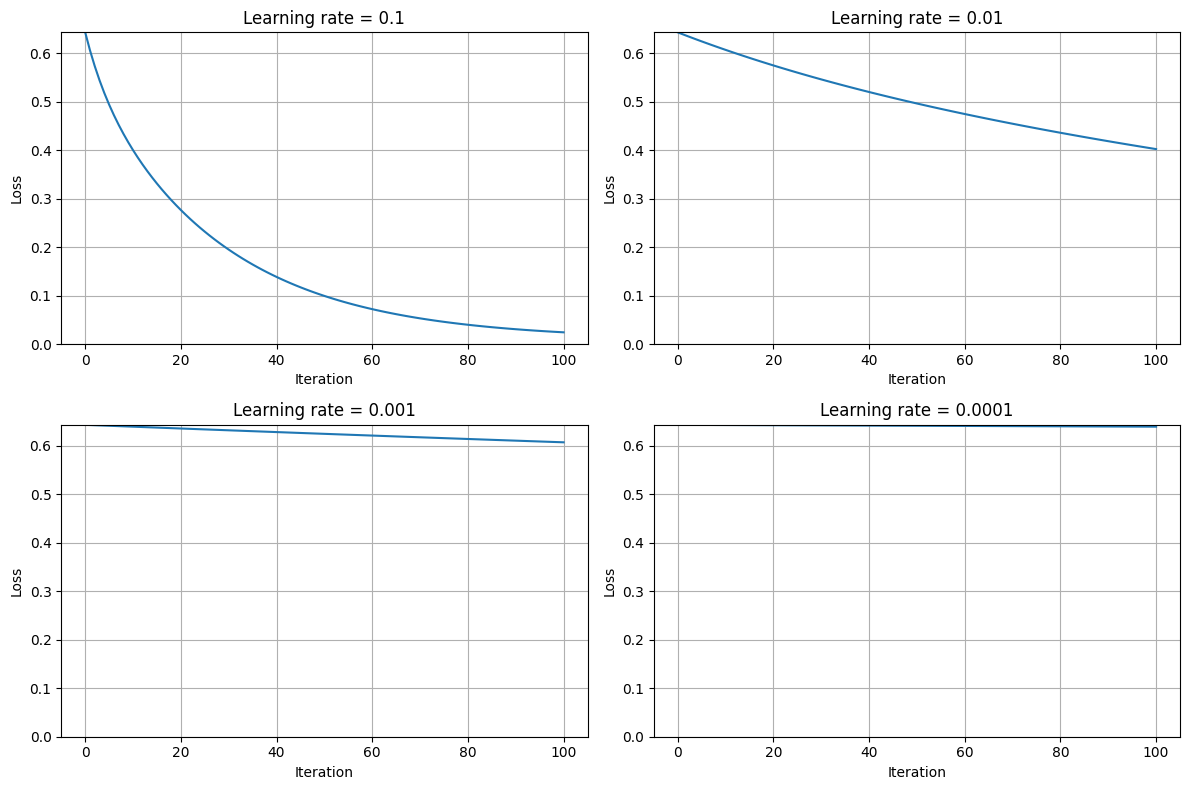

In [ ]:
def plot_gd(trajectory: List[np.ndarray], loss: BaseLoss, X: np.ndarray, y: np.ndarray):
    """
    Визуализирует траекторию градиентного спуска
    :param trajectory: список векторов весов на каждом шаге
    :param loss: объект функции потерь для вычисления значения
    :param X: матрица признаков
    :param y: вектор целевых значений
    """
    losses = [loss.calc_loss(X, y, w) for w in trajectory]
    plt.plot(losses)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.grid(True)

np.random.seed(42)
X = np.random.rand(100, 2)  # 100 объектов, 2 признака
true_w = np.array([2.0, -1.5])
y = X @ true_w + np.random.normal(0, 0.1, 100)

w_init = np.zeros(2) #веса
loss = MSELoss()


learning_rates = [0.1, 0.01, 0.001, 0.0001] # ращные длины шага
n_iterations = 100

plt.figure(figsize=(12, 8))
for i, lr in enumerate(learning_rates, 1):
    trajectory = gradient_descent(w_init, X, y, loss, lr, n_iterations)
    plt.subplot(2, 2, i)
    plot_gd(trajectory, loss, X, y)
    plt.title(f'Learning rate = {lr}')
    plt.ylim(0, loss.calc_loss(X, y, w_init))

plt.tight_layout()
plt.show()

# Задание 1.4 (5/8 балла):
Реализуйте функцию stochastic_gradient_descent.

Функция должна принимать все те же параметры, что и функция gradient_descent, но ещё параметр batch_size, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке X, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать np.random.choice с правильным параметром size, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив X:

batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]

In [ ]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    w_current = w_init.copy()
    trajectory = [w_current.copy()]

    for _ in range(n_iterations):
        # батч
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        # градиент на батче
        grad = loss.calc_grad(X_batch, y_batch, w_current)

        w_current = w_current - lr * grad
        trajectory.append(w_current.copy())

    return trajectory

# Задание 1.5 (5/8 балла):
При помощи функций stochastic_gradient_descent и  plot_gd нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра lr) и размера подвыборки (параметра batch_size). Используйте не менее четырёх разных значений для lr и batch_size.

Сделайте и опишите свои выводы о том, как параметры  lr и batch_size влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших batch_size?

Обратите внимание, что в нашем датасете всего 300 объектов, так что batch_size больше этого числа не будет иметь смысла.

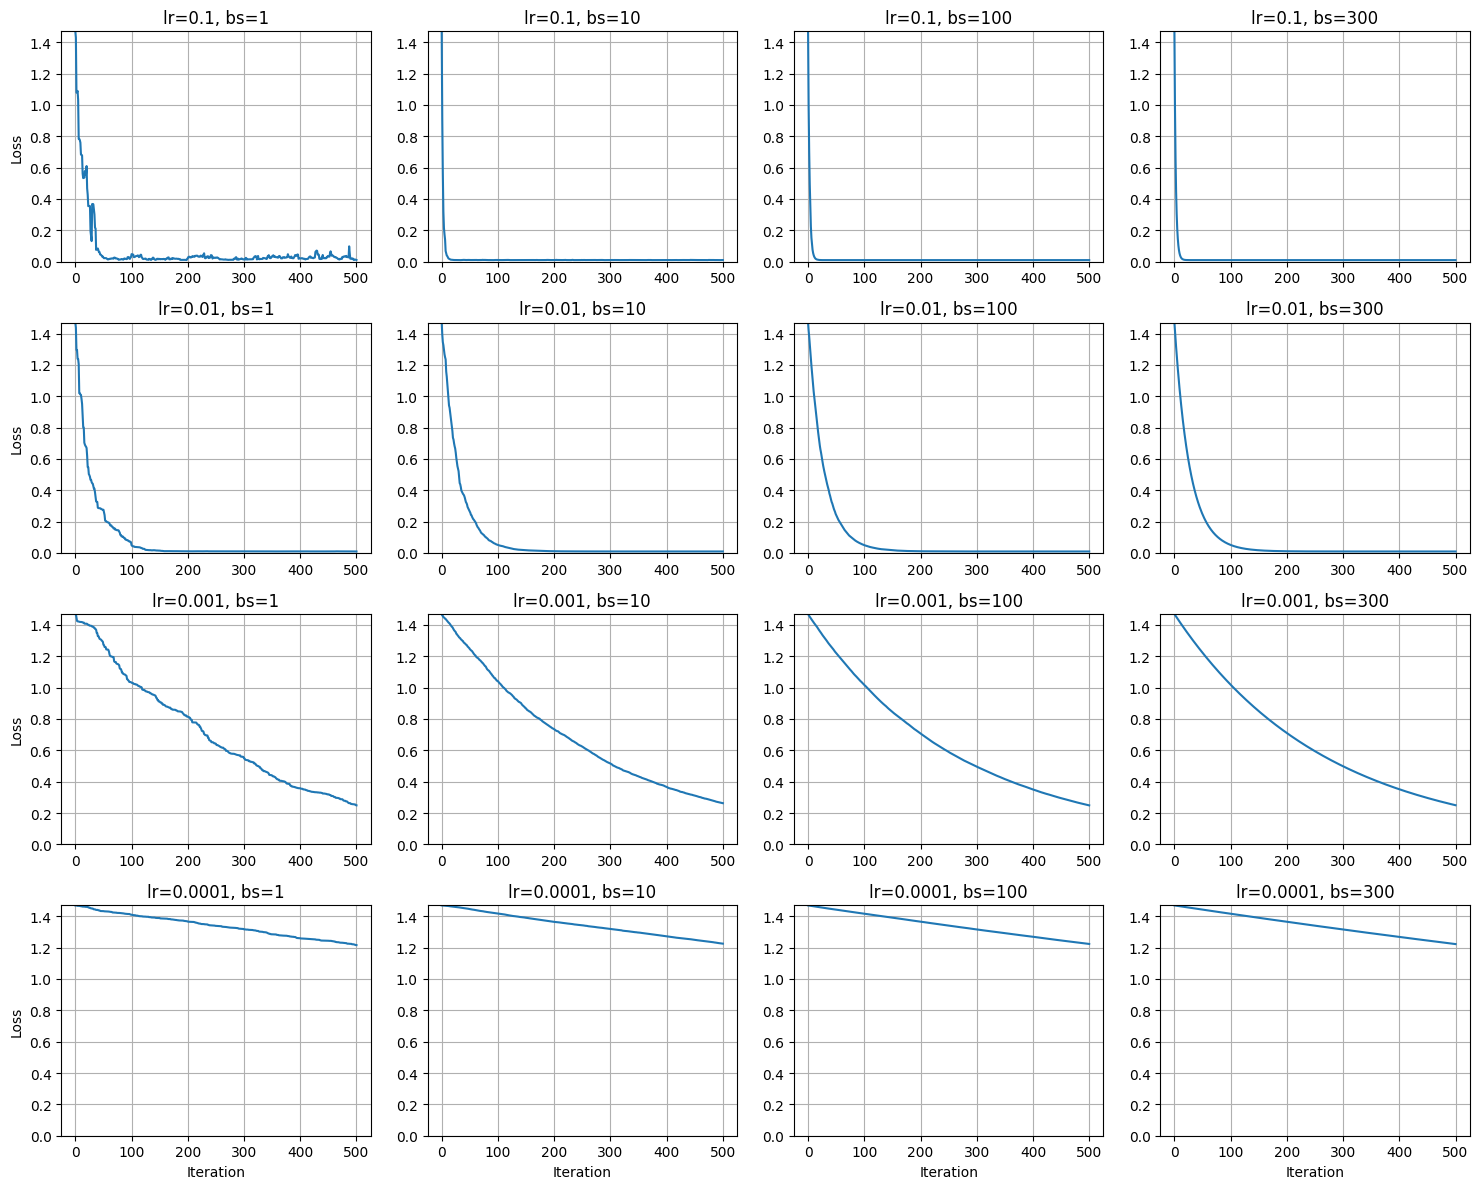

In [ ]:
np.random.seed(42)
n_objects = 300
n_features = 5
X = np.random.randn(n_objects, n_features)
true_w = np.random.randn(n_features)
y = X @ true_w + np.random.normal(0, 0.1, n_objects)

w_init = np.zeros(n_features)
loss = MSELoss()
n_iterations = 500

learning_rates = [0.1, 0.01, 0.001, 0.0001]
batch_sizes = [1, 10, 100, 300]

plt.figure(figsize=(15, 12))

for i, lr in enumerate(learning_rates, 1):
    for j, batch_size in enumerate(batch_sizes, 1):
        plt.subplot(len(learning_rates), len(batch_sizes), (i-1)*len(batch_sizes)+j)

        trajectory = stochastic_gradient_descent(
            w_init, X, y, loss, lr, batch_size, n_iterations)

        losses = [loss.calc_loss(X, y, w) for w in trajectory]
        plt.plot(losses)
        plt.title(f'lr={lr}, bs={batch_size}')
        plt.grid(True)
        plt.ylim(0, loss.calc_loss(X, y, w_init))

        if j == 1:
            plt.ylabel('Loss')
        if i == len(learning_rates):
            plt.xlabel('Iteration')

plt.tight_layout()
plt.show()

# Задание 1.6 (5/8 балла):
Реализуйте функцию stochastic_gradient_descent на этот раз с затухающим шагом по формуле выше. Параметр
 возьмите равным 1. Параметр  возьмите из нового аргумента функции p.

In [ ]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Стохастический градиентный спуск с затухающим шагом
    :param w_init: начальные веса
    :param X: матрица признаков
    :param y: вектор целевых значений
    :param loss: функция потерь
    :param lr: начальный learning rate
    :param batch_size: размер батча
    :param p: параметр затухания
    :param n_iterations: количество итераций
    :return: история весов
    """
    w_current = w_init.copy()
    trajectory = [w_current.copy()]

    for t in range(1, n_iterations + 1):
        # текущий learning rate с затуханием
        current_lr = lr / (t ** p)

        # случайный батч
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        # градиент на батче
        grad = loss.calc_grad(X_batch, y_batch, w_current)

        # обновили веса с текущим learning rate
        w_current = w_current - current_lr * grad
        trajectory.append(w_current.copy())

    return trajectory

# Задание 1.7 (5/8 балла):
При помощи новой функции stochastic_gradient_descent и функции plot_gd нарисуйте траекторию градиентного спуска для разных значений параметра p. Используйте не менее четырёх разных значений для p. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1. Параметр lr возьмите равным 0.01, а параметр batch_size равным 10.

Сделайте и опишите свои выводы о том, как параметр p влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

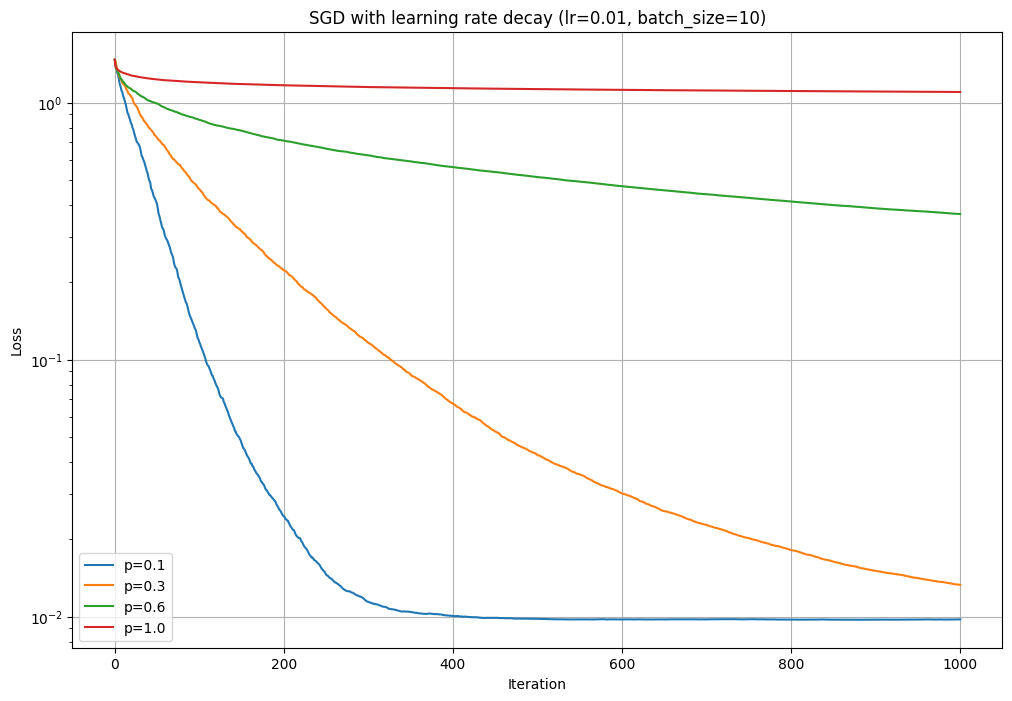

In [ ]:
np.random.seed(42)
n_objects = 300
n_features = 5
X = np.random.randn(n_objects, n_features)
true_w = np.random.randn(n_features)
y = X @ true_w + np.random.normal(0, 0.1, n_objects)

w_init = np.zeros(n_features)
loss = MSELoss()
n_iterations = 1000
lr = 0.01
batch_size = 10

p_values = [0.1, 0.3, 0.6, 1.0]

plt.figure(figsize=(12, 8))

for p in p_values:
    trajectory = stochastic_gradient_descent(
        w_init, X, y, loss, lr, batch_size, p, n_iterations)

    losses = [loss.calc_loss(X, y, w) for w in trajectory]

    plt.plot(losses, label=f'p={p}')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('SGD with learning rate decay (lr=0.01, batch_size=10)')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

# Задание 1.8 (5/8 балла):
Сравните сходимость обычного градиентного спуска и стохастичекой версии: Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода calc_loss, используя  и  из датасета и  с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр batch_size возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

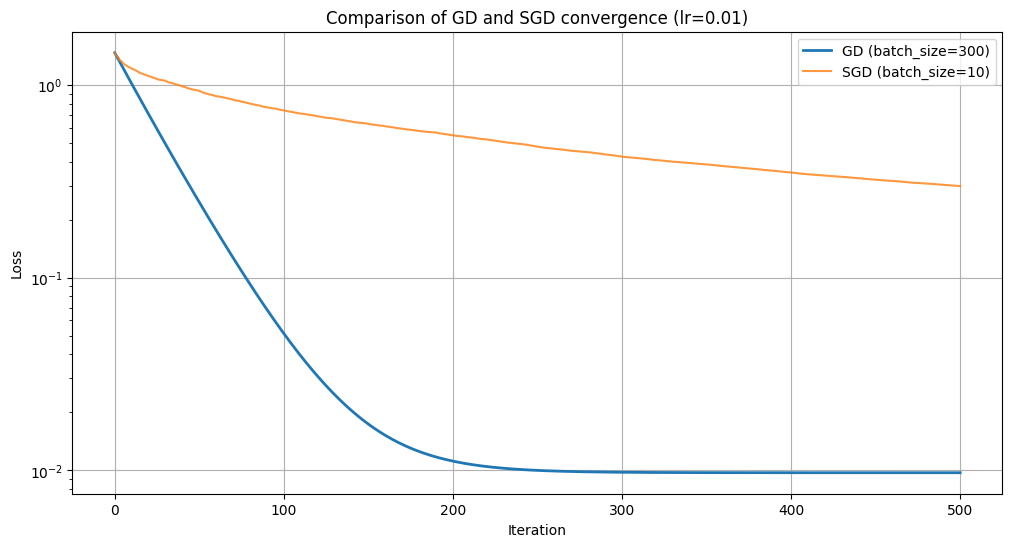

In [ ]:
np.random.seed(42)
n_objects = 300
n_features = 5
X = np.random.randn(n_objects, n_features)
true_w = np.random.randn(n_features)
y = X @ true_w + np.random.normal(0, 0.1, n_objects)

w_init = np.zeros(n_features)
loss = MSELoss()
n_iterations = 500
lr = 0.01

gd_trajectory = gradient_descent(w_init, X, y, loss, lr, n_iterations)
gd_losses = [loss.calc_loss(X, y, w) for w in gd_trajectory]

sgd_trajectory = stochastic_gradient_descent(w_init, X, y, loss, lr, 10, 0.5, n_iterations)
sgd_losses = [loss.calc_loss(X, y, w) for w in sgd_trajectory]

plt.figure(figsize=(12, 6))
plt.plot(gd_losses, label='GD (batch_size=300)', linewidth=2)
plt.plot(sgd_losses, label='SGD (batch_size=10)', alpha=0.8)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Comparison of GD and SGD convergence (lr=0.01)')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

# Часть 2. Линейная регрессия (5 баллов)
Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки sklearn.

В методе fit мы будем подбирать веса w при помощи градиентного спуска нашим методом gradient_descent.

В методе predict мы будем применять нашу регрессию к датасету.

# Задание 2.1 (5/8 балла):
Допишите код в методах fit и predict класса LinearRegression.

В методе fit вам нужно как-то инициализировать веса w, применить gradient_descent и сохранить последнюю w из траектории.

В методе predict вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в self.loss. Его нужно использовать в fit для gradient_descent.

In [ ]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        # инициализируем веса нулями (размерность n_features + 1 для bias)
        w_init = np.zeros(X.shape[1])

        trajectory = gradient_descent(
            w_init=w_init,
            X=X,
            y=y,
            loss=self.loss,
            lr=self.lr,
            n_iterations=1000
        )

        self.w = trajectory[-1]

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        return X @ self.w

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр loss при инициализации.

Пока у нас нет никаких классов кроме MSELoss, но скоро они появятся.

Для MSELoss мы бы создавали наш объект линейной регрессии, например, так:

In [ ]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [ ]:
import pandas as pd

X_raw = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [ ]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

# Задание 2.2 (5/8 балла):
Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

Разделите датасет на обучающую и тестовую выборку

Заполните пропуски

Нормализуйте числовые признаки

Закодируйте категориальные переменные

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
df = pd.read_csv('cars_data.csv')

df = df.drop(columns=['Unnamed: 0'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # заполнение пропусков медианой
    ('scaler', StandardScaler())  # стандартная нормализация
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

y_imputer = SimpleImputer(strategy='median')
y_train = y_imputer.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test = y_imputer.transform(y_test.values.reshape(-1, 1)).ravel()



# Задание 2.3 (5/8 балла):
Обучите написанную вами линейную регрессию на обучающей выборке

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_processed, y_train)

coefficients = model.coef_
intercept = model.intercept_

# Задание 2.4 (5/8 балла):
Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода mean_squared_error из sklearn.metrics.

In [ ]:
from sklearn.metrics import mean_squared_error

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"MSE на обучающей выборке: {train_mse:.2f}")
print(f"MSE на тестовой выборке: {test_mse:.2f}")

MSE на обучающей выборке: 1540147.02
MSE на тестовой выборке: 11234426.51


# Задание 2.5 (5/8 балла):
Реализуйте класс MSEL2Loss.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора w — это bias (в классе LinearRegression к матрице X добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из w при подсчёте слагаемого
 в calc_loss и занулить его при подсчёте слагаемого  в calc_grad.

In [ ]:
import numpy as np

class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        residuals = X.dot(w) - y
        mse = np.mean(residuals**2)

        l2_penalty = self.coef * np.sum(w[:-1]**2)  # w[:-1] - все веса кроме bias

        return mse + l2_penalty

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        n_samples = X.shape[0]

        grad_mse = (2/n_samples) * X.T.dot(X.dot(w) - y)

        grad_l2 = 2 * self.coef * w
        grad_l2[-1] = 0  # зануляем градиент для bias

        return grad_mse + grad_l2

In [ ]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

# Задание 2.6 (5/8 балла):
Обучите регрессию с лоссом MSEL2Loss. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.


MSE train: 5016576.28 | test: 12208305.63
Разница: 7191729.35
MSE train: 5043677.23 | test: 12221003.15
Разница: 7177325.92
MSE train: 5290974.70 | test: 12351080.37
Разница: 7060105.67
MSE train: 7495168.41 | test: 14071191.78
Разница: 6576023.37
MSE train: 13448903.52 | test: 20690146.76
Разница: 7241243.24
MSE train: 30484705.25 | test: 42444582.74
Разница: 11959877.49

Лучшая модель с регуляризацией:
MSE train: 5043677.23 | test: 12221003.15
Разница: 7177325.92


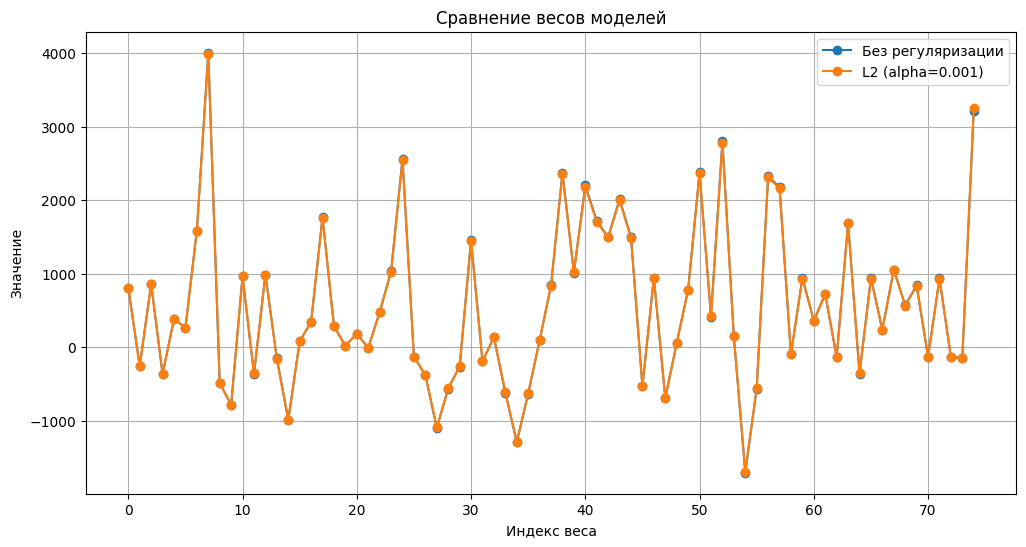

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

class LinearRegression:
    def __init__(self, loss=None):
        """
        :param loss: объект функции потерь (по умолчанию MSELoss)
        """
        self.loss = loss if loss is not None else MSELoss()
        self.w = None  # веса будут инициализированы при вызове fit()
        self.lr = 0.01  # фиксированная скорость обучения

    def fit(self, X, y, n_iter=1000):
        """
        :param n_iter: количество итераций градиентного спуска
        """
        self.w = np.zeros(X.shape[1])

        # градиентный спуск
        for _ in range(n_iter):
            grad = self.loss.calc_grad(X, y, self.w)
            self.w -= self.lr * grad

        return self

    def predict(self, X):
        assert self.w is not None, "Model not fitted yet!"
        return X.dot(self.w)

X_train_reg = np.hstack([X_train_processed, np.ones((X_train_processed.shape[0], 1))])
X_test_reg = np.hstack([X_test_processed, np.ones((X_test_processed.shape[0], 1))])

def train_and_evaluate(alpha=None):
    if alpha is None:
        model = LinearRegression()
    else:
        model = LinearRegression(MSEL2Loss(alpha))

    model.fit(X_train_reg, y_train)

    train_pred = model.predict(X_train_reg)
    test_pred = model.predict(X_test_reg)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    print(f"MSE train: {train_mse:.2f} | test: {test_mse:.2f}")
    print(f"Разница: {test_mse - train_mse:.2f}")

    return model, test_mse

model_no_reg, mse_no_reg = train_and_evaluate()

best_alpha, best_mse = None, float('inf')
for alpha in [0.001, 0.01, 0.1, 1, 10]:
    _, current_mse = train_and_evaluate(alpha)
    if current_mse < best_mse:
        best_mse = current_mse
        best_alpha = alpha

print("\nЛучшая модель с регуляризацией:")
model_l2, _ = train_and_evaluate(best_alpha)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(model_no_reg.w, 'o-', label='Без регуляризации')
plt.plot(model_l2.w, 'o-', label=f'L2 (alpha={best_alpha})')
plt.legend()
plt.title("Сравнение весов моделей")
plt.xlabel("Индекс веса")
plt.ylabel("Значение")
plt.grid(True)
plt.show()

#ps я мучилась часа 3 у меня ничего не вышло:((((((
  ну хотя бы график какой-то вывелся уже победа т.т

# Задание 2.7 (5/8 балла):
Реализуйте класс HuberLoss.

Он должен вычислять лосс и градиент по формулам выше.

In [ ]:
import numpy as np

class HuberLoss(BaseLoss):
    def __init__(self, epsilon: float = 1.0):
        """
        :param epsilon: параметр, определяющий переход между квадратичной и линейной областями
        """
        self.epsilon = epsilon

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Вычисление значения Huber Loss
        """
        residuals = X.dot(w) - y
        abs_res = np.abs(residuals)

        losses = np.where(
            abs_res <= self.epsilon,
            0.5 * residuals**2,
            self.epsilon * (abs_res - 0.5 * self.epsilon)
        )

        return np.mean(losses)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Вычисление градиента Huber Loss
        """
        residuals = X.dot(w) - y
        abs_res = np.abs(residuals)

        derivatives = np.where(
            abs_res <= self.epsilon,
            residuals,
            self.epsilon * np.sign(residuals)
        )

        return X.T.dot(derivatives) / X.shape[0]

# Задание 2.8 (5/8 балла):
Обучите регрессию с лоссом HuberLoss. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c MSELoss.

Сравнение HuberLoss и MSELoss

MSELoss результаты:
- MSE на обучении: 5016576.28
- MSE на тесте: 12208305.63
- Разница (переобучение): 7191729.35

HuberLoss (ε=0.5) результаты:
- MSE на обучении: 228574849.00
- MSE на тесте: 255918675.43
- Разница (переобучение): 27343826.43

HuberLoss (ε=1.0) результаты:
- MSE на обучении: 227769890.12
- MSE на тесте: 255107350.59
- Разница (переобучение): 27337460.47

HuberLoss (ε=1.5) результаты:
- MSE на обучении: 226967024.56
- MSE на тесте: 254298078.13
- Разница (переобучение): 27331053.57

HuberLoss (ε=2.0) результаты:
- MSE на обучении: 226166252.32
- MSE на тесте: 253490858.06
- Разница (переобучение): 27324605.74

Лучшая модель HuberLoss:

HuberLoss (лучший ε=2.0) результаты:
- MSE на обучении: 226166252.32
- MSE на тесте: 253490858.06
- Разница (переобучение): 27324605.74

Улучшение на тестовой выборке: -1976.38%


<ipython-input-138-b5537758942d>:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([errors_mse, errors_huber], labels=['MSELoss', 'HuberLoss'])


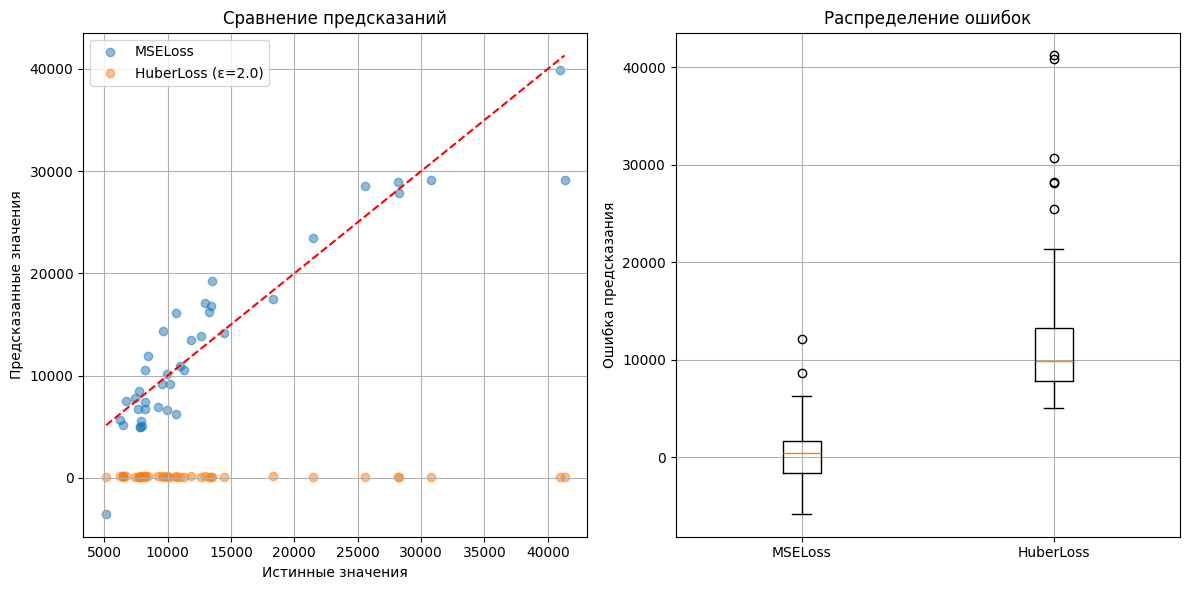

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

X_train_huber = np.hstack([X_train_processed, np.ones((X_train_processed.shape[0], 1))])
X_test_huber = np.hstack([X_test_processed, np.ones((X_test_processed.shape[0], 1))])

def train_and_evaluate(loss, loss_name):
    model = LinearRegression(loss=loss)
    model.fit(X_train_huber, y_train)

    train_pred = model.predict(X_train_huber)
    test_pred = model.predict(X_test_huber)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    print(f"\n{loss_name} результаты:")
    print(f"- MSE на обучении: {train_mse:.2f}")
    print(f"- MSE на тесте: {test_mse:.2f}")
    print(f"- Разница (переобучение): {test_mse - train_mse:.2f}")

    return model, train_mse, test_mse

print("Сравнение HuberLoss и MSELoss")
mse_model, mse_train, mse_test = train_and_evaluate(MSELoss(), "MSELoss")

best_eps, best_test_mse = None, float('inf')
for epsilon in [0.5, 1.0, 1.5, 2.0]:
    huber = HuberLoss(epsilon=epsilon)
    _, _, test_mse = train_and_evaluate(huber, f"HuberLoss (ε={epsilon})")

    if test_mse < best_test_mse:
        best_test_mse = test_mse
        best_eps = epsilon

print("\nЛучшая модель HuberLoss:")
huber_model, huber_train, huber_test = train_and_evaluate(
    HuberLoss(epsilon=best_eps),
    f"HuberLoss (лучший ε={best_eps})"
)

improvement = (mse_test - huber_test) / mse_test * 100
print(f"\nУлучшение на тестовой выборке: {improvement:.2f}%")

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, mse_model.predict(X_test_huber), alpha=0.5, label='MSELoss')
plt.scatter(y_test, huber_model.predict(X_test_huber), alpha=0.5, label=f'HuberLoss (ε={best_eps})')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('Сравнение предсказаний')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
errors_mse = y_test - mse_model.predict(X_test_huber)
errors_huber = y_test - huber_model.predict(X_test_huber)
plt.boxplot([errors_mse, errors_huber], labels=['MSELoss', 'HuberLoss'])
plt.title('Распределение ошибок')
plt.ylabel('Ошибка предсказания')
plt.grid(True)

plt.tight_layout()
plt.show()

# Задание 3 (0.08/8 балла)
Вставьте ваш любимый мем 2025 в ячейку ниже:

![Alt text](https://i.imgur.com/dUkaaM2.jpeg)

Еще есть стикерпак с этой собакой, он имбовый, мой любимый
https://t.me/addstickers/Dog_apple_by_MoiStikiBot

# БОНУС (2 балла)
Градиентный спуск — далеко не единственный метод оптимизации. Другой очень известный метод называется "Алгоритм имитации отжига". Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.
Задание (2 балла): Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3. Это может выглядеть, например, так:

new_w = old_w + np.random.standard_t(3, size=old_w.shape)
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

Проверка размерностей:
X_train: (164, 74), y_train: (164,)
X_test: (41, 74), y_test: (41,)

Ошибка при предсказании: shapes (41,74) and (75,) not aligned: 74 (dim 1) != 75 (dim 0)
Размер X_test_processed: (41, 74)
Размер весов sa_model: 75
Размер весов gd_model: 75


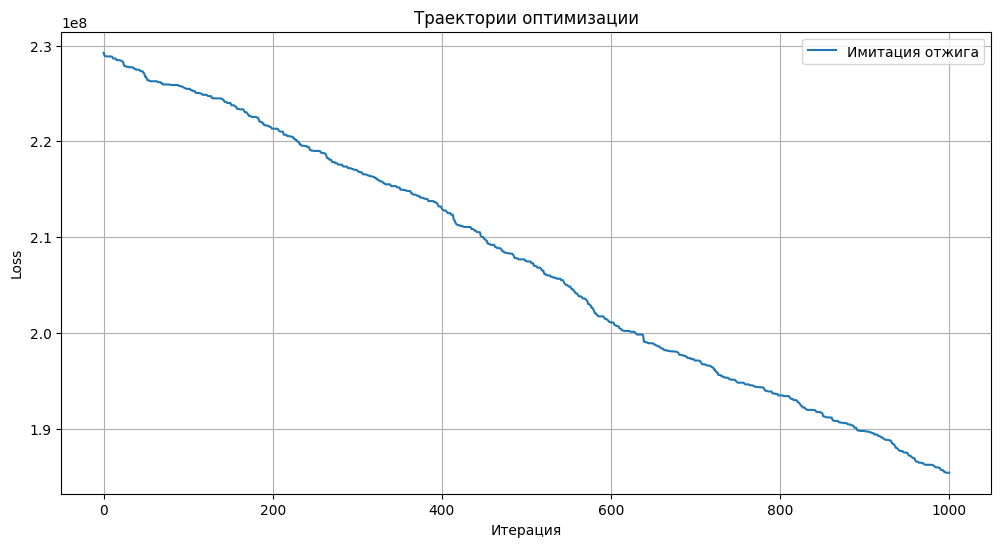

In [ ]:
import numpy as np
from scipy.stats import t
from sklearn.metrics import mean_squared_error

class SimulatedAnnealingRegressor:
    def __init__(self, loss=MSELoss(), temp=100.0, cooling_rate=0.95, t_df=3):
        self.loss = loss
        self.temp = temp
        self.cooling_rate = cooling_rate
        self.t_df = t_df
        self.w = None
        self.loss_history = []

    def fit(self, X, y, n_iter=1000):
        X = np.hstack([X, np.ones((X.shape[0], 1))])

        self.w = np.random.randn(X.shape[1])
        current_loss = self.loss.calc_loss(X, y, self.w)
        self.loss_history.append(current_loss)

        for i in range(n_iter):
            new_w = self.w + t.rvs(self.t_df, size=self.w.shape)

            new_loss = self.loss.calc_loss(X, y, new_w)

            if new_loss < current_loss or np.random.rand() < np.exp(-(new_loss - current_loss)/self.temp):
                self.w = new_w
                current_loss = new_loss

            self.loss_history.append(current_loss)
            self.temp *= self.cooling_rate

        return self

    def predict(self, X):
        assert self.w is not None, "Model not fitted yet!"
        X = np.hstack([X, np.ones((X.shape[0], 1))])
        return X.dot(self.w)

print("Проверка размерностей:")
print(f"X_train: {X_train_processed.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test_processed.shape}, y_test: {y_test.shape}")


sa_model = SimulatedAnnealingRegressor(temp=100, cooling_rate=0.99, t_df=3)
sa_model.fit(X_train_processed, y_train, n_iter=1000)


gd_model = LinearRegression(loss=MSELoss())
gd_model.fit(np.hstack([X_train_processed, np.ones((X_train_processed.shape[0], 1))]), y_train)

try:
    sa_pred = sa_model.predict(X_test_processed)
    gd_pred = gd_model.predict(X_test_processed)
except Exception as e:
    print(f"\nОшибка при предсказании: {str(e)}")
    print(f"Размер X_test_processed: {X_test_processed.shape}")
    print(f"Размер весов sa_model: {len(sa_model.w) if sa_model.w is not None else 'None'}")
    print(f"Размер весов gd_model: {len(gd_model.w) if gd_model.w is not None else 'None'}")

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(sa_model.loss_history, label='Имитация отжига')
plt.title('Траектории оптимизации')
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()